<h4>定义 Определение</h4>

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

In [201]:
type = {"Iris-virginica":0,"Iris-versicolor":1,"Iris-setosa":2}#将类型变为数字 Преобразование типов в числа
name = ["Iris-virginica","Iris-versicolor","Iris-setosa"]#将数字变为类型 Преобразование чисел в типы

<h4>读取文件并把向量数字化 Чтение файла и векторизация данных</h4>

In [202]:
file = 'iris.csv'
df = pd.read_csv(file, encoding='utf-8')
array = df.to_numpy()
for j in range(len(array)):
    array[j][4] = type[array[j][4]]

<h4>提取初始以及目标向量 Извлечение начальных и целевых векторов</h4>

In [203]:
X = array[:, :4]
Y = array[:, 4]
num_INP = len(array)

<h4>可视化（AI生成） Визуализация(AI-gen)</h4>

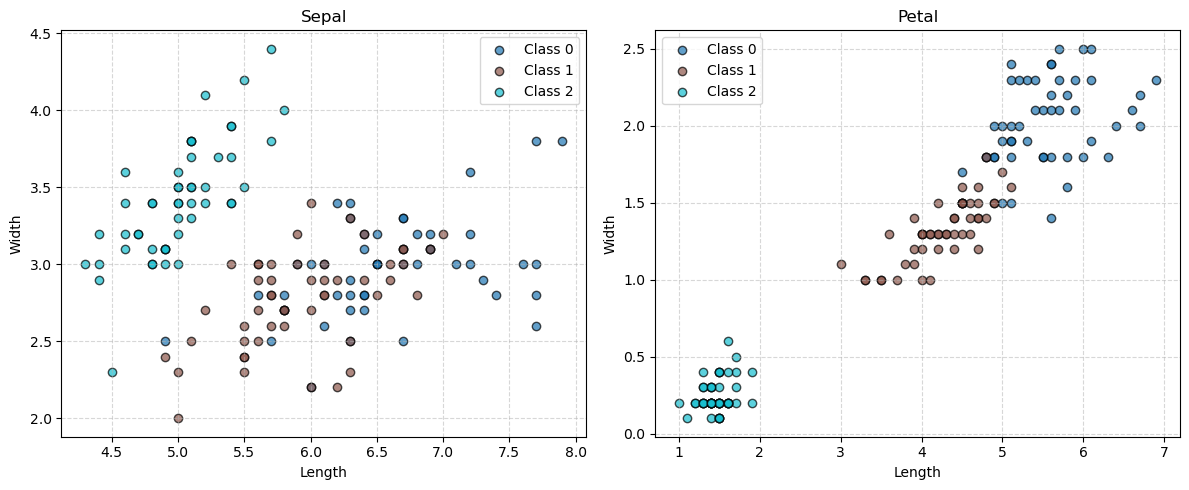

In [204]:
unique_labels = np.unique(Y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax1.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax1.set_xlabel('Length')
ax1.set_ylabel('Width')
ax1.set_title('Sepal')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax2.scatter(X[mask, 2], X[mask, 3], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax2.set_xlabel('Length')
ax2.set_ylabel('Width')
ax2.set_title('Petal')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h4>选择数据来源，输入0重新输入，输入其他数字使用保存的参数 Выберите источник данных, введите 0 для повторного ввода, введите другую цифру для использования сохраненных параметров</h4>

In [205]:
mode = int(input())#0为重置，1为继续训练，其他数字为跳过训练 0 - сброс, 1 - продолжение обучения, другие числа - пропуск обучения
if not mode:
    a0, a1, a2, a3, a4 = float(0),float(0),float(0),float(0),float(0)
else:
     with open('linear.txt', 'r') as f:
        line = f.readline().strip()
        nums = line.split()
        a0, a1, a2, a3, a4 = map(float, nums)
print([a0,a1,a2,a3,a4])

[1.1198745427161394, 0.20953976979907338, 0.1065592344403735, -0.23821414812412126, -0.650356822019536]


<h4>训练及模型 Обучение и модель</h4>
使用线性模型：Использование линейной модели:<br>
y=floor(a0+ak xk)

In [206]:
epsilon = 0.05*num_INP#定义容许误差 Определение допустимой погрешности
maxTime = int(1E5)
alpha = 1E-5

def func(x1,x2,x3,x4):#训练用模型 Модель для обучения
    return a0+a1*x1+a2*x2+a3*x3+a4*x4

def err(inpvec):#误差 Погрешность
    return (func(inpvec[0],inpvec[1],inpvec[2],inpvec[3])-inpvec[4])**2

def total_err():#总误差 Общая погрешность
    out=0
    for i in range(num_INP):
        out+=(err([X[i][0],X[i][1],X[i][2],X[i][3],Y[i]]))
    return out

def gradient():#基于数学分析的梯度解析式 Аналитическое выражение градиента на основе математического анализа
    out = [0,0,0,0,0]
    for j in range(num_INP):
        global a0, a1,a2, a3, a4
        temp = 2*(a0+a1*X[j][0]+a2*X[j][1]+a3*X[j][2]+a4*X[j][3]-Y[j])
        out[0] += temp
        out[1] += temp*X[j][0]
        out[2] += temp*X[j][1]
        out[3] += temp*X[j][2]
        out[4] += temp*X[j][3]
    return out

def train():#梯度下降 Градиентный спуск
    for i in range(maxTime):
        global a0, a1,a2, a3, a4
        grad = gradient()
        a0 += -alpha*grad[0]
        a1 += -alpha*grad[1]*X[j][0]
        a2 += -alpha*grad[2]*X[j][1]
        a3 += -alpha*grad[3]*X[j][2]
        a4 += -alpha*grad[4]*X[j][3]
        if  total_err() < epsilon:
            break

def roughlyEnoughInt(inp):#四舍五入 Округление
    if inp-floor(inp) <0.5:
        if inp<0:
            return 0
        else:
            return floor(inp)
    else:
        if floor(inp)+1>2:
            return 2
        else:
            return floor(inp)+1

def predict(inpvec):#结果模型 Итоговая модель
    return roughlyEnoughInt(a0+a1*inpvec[0]+a2*inpvec[1]+a3*inpvec[2]+a4*inpvec[3])

print("训练前总误差")#Русский: Общая погрешность до обучения
print(total_err())
if mode != 1 or (not mode):
    train()
    print("训练后总误差")#Русский: Общая погрешность после обучения
    print(total_err())
else:
    print("未进行训练")#Русский: Обучение не проводилось

#写入训练数据到硬盘存储 Запись обучающих данных на диск
with open('linear.txt', 'w') as f:
    f.write(f"{a0} {a1} {a2} {a3} {a4}")

训练前总误差
7.4999842175686195
未进行训练


<h4>测试模型 Тест Моделя</h4>

In [207]:
output_file = 'predictions.csv' # 输出文件 Выходной файл
predicted_names = []
outX1 = []
outX2 = []
outX3 = []
outX4 = []
for i in range(num_INP):
    outX1.append(X[i][0])
    outX2.append(X[i][1])
    outX3.append(X[i][2])
    outX4.append(X[i][3])
    pred_num = predict(X[i])          # 返回数字标签 0,1,2 Возвращает числовые метки 0,1,2
    pred_name = name[pred_num]          # 转换为品种名称 Преобразование в названия сортов
    predicted_names.append(pred_name)

# 写入CSV Запись в CSV
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species'])         # 表头 Заголовок
    index = 0
    for name_label in predicted_names:
        writer.writerow([outX1[index],outX2[index],outX3[index],outX4[index],name_label])
        index += 1

print(f"预测完成，结果已保存至 {output_file}")#Русский: Прогноз завершен, результат сохранен в {output_file}

预测完成，结果已保存至 predictions.csv


<h4>准确度检查 Проверка точности</h4>

In [208]:
Trues = 0
Faults = 0
for i in range(num_INP):
    if type[predicted_names[i]] == Y[i]:
        Trues += 1
    else:
        Faults += 1

precision = Trues/(Trues+Faults)
print("准确率：")#Русский: Точность:
print(f"准确率：{precision*100:.2f}%") 
print("正确数：")#Русский: Количество правильных:
print(Trues)
print("错误数：")#Русский: Количество ошибок:
print(Trues)

准确率：
准确率：97.33%
正确数：
146
错误数：
146
